<a href="https://colab.research.google.com/github/Rosierobber/python-learner/blob/main/experiment-codespace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Condition,Accuracy,Error Rate
0,Clean,92.4,7.6
1,JPEG Compression,81.7,18.3
2,Gaussian Blur,76.3,23.7
3,Gaussian Noise,69.8,30.2


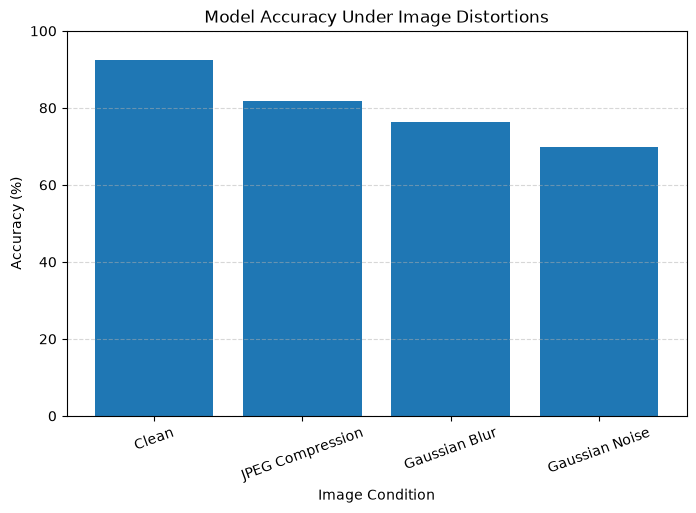

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Example experiment results for a research paper
results = {
    "Condition": ["Clean", "JPEG Compression", "Gaussian Blur", "Gaussian Noise"],
    "Accuracy": [92.4, 81.7, 76.3, 69.8],
    "Error Rate": [7.6, 18.3, 23.7, 30.2]
}

df = pd.DataFrame(results)

# Show table
display(df)

# Create figure
plt.figure(figsize=(8, 5))
plt.bar(df["Condition"], df["Accuracy"])

plt.title("Model Accuracy Under Image Distortions")
plt.xlabel("Image Condition")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
%pip install pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 13.5 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 15.8 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 20.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 21.7 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 16.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# -------------------------------------------------------------
# STEP 1: Install Dependencies
# -------------------------------------------------------------
!pip install -q imbalanced-ensemble imbalanced-learn scikit-learn openml pandas numpy

import numpy as np
import pandas as pd
import openml
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, auc, balanced_accuracy_score, f1_score
from imbens.ensemble import SelfPacedEnsembleClassifier, BalancedRandomForestClassifier

# -------------------------------------------------------------
# STEP 2: Load Imbalanced Tabular Dataset (OpenML ID: 1067 - pc1 software defect)
# -------------------------------------------------------------
print("[+] Loading OpenML Dataset...")
dataset = openml.datasets.get_dataset(1067)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

# Encode target labels to binary (0 and 1)
y = (y == y.unique()[1]).astype(int)

# Handle missing values & scale numeric data simply
X = X.fillna(X.median())
X = pd.get_dummies(X, drop_first=True)

print(f"Dataset Shape: {X.shape}")
print(f"Class Distribution: 0 -> {sum(y==0)}, 1 -> {sum(y==1)} (IR: {round(sum(y==0)/sum(y==1), 2)}:1)")

# -------------------------------------------------------------
# STEP 3: Define Evaluation Metric (AUPRC)
# -------------------------------------------------------------
def compute_auprc(y_true, y_pred_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    return auc(recall, precision)

# -------------------------------------------------------------
# STEP 4: Run 5-Fold Stratified Cross-Validation
# -------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Base DecisionTree": DecisionTreeClassifier(random_state=42),
    "SelfPacedEnsemble": SelfPacedEnsembleClassifier(random_state=42),
    "BalancedRandomForest": BalancedRandomForestClassifier(random_state=42)
}

results = []

print("\n[+] Running 5-Fold Stratified CV Evaluation...")
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for name, model in models.items():
        model.fit(X_train, y_train)

        # Get predictions
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = model.predict(X_test)

        y_pred = model.predict(X_test)

        # Calculate Metrics
        auprc = compute_auprc(y_test, y_proba)
        bac = balanced_accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        results.append({
            "Fold": fold + 1,
            "Model": name,
            "AUPRC": auprc,
            "BAC": bac,
            "Macro-F1": f1
        })

# -------------------------------------------------------------
# STEP 5: Display & Save Aggregate Results
# -------------------------------------------------------------
df_res = pd.DataFrame(results)
summary = df_res.groupby("Model")[["AUPRC", "BAC", "Macro-F1"]].agg(["mean", "std"])
print("\n=== FINAL BENCHMARK RESULTS ===")
print(summary)

# Save results for LaTeX generation
df_res.to_csv("experiment_results.csv", index=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.0/752.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 39.7 MB/s eta 0:00:00
[+] Loading OpenML Dataset...
Dataset Shape: (2109, 21)
Class Distribution: 0 -> 1783, 1 -> 326 (IR: 5.47:1)

[+] Running 5-Fold Stratified CV Evaluation...

=== FINAL BENCHMARK RESULTS ===
                         AUPRC                 BAC            Macro-F1  \
                          mean       std      mean       std      mean   
Model                                                                    
BalancedRandomForest  0.430746  0.042119  0.724879  0.016133  0.621306  